In [1]:
import pandas as pd

# Load files
rbp1 = pd.read_csv("rbp1_insulation_30kb.tsv", sep="\t")
ctrl = pd.read_csv("ctrl_insulation_30kb.tsv", sep="\t")

# Merge on genomic bins
df = ctrl.merge(
    rbp1,
    on=["chrom","start","end"],
    suffixes=("_ctrl","_rbp1")
)

# Drop NaNs
df = df.dropna(subset=["log2_insulation_score_30000_ctrl",
                       "log2_insulation_score_30000_rbp1"])

df.head()

,chrom,start,end,log2_insulation_score_30000_ctrl,boundary_strength_30000_ctrl,log2_insulation_score_30000_rbp1,boundary_strength_30000_rbp1
179,chr1,1790000,1800000,2.496228,NaN,1.990243,NaN
180,chr1,1800000,1810000,2.408196,NaN,2.000640,NaN
181,chr1,1810000,1820000,2.264915,NaN,1.870121,NaN
182,chr1,1820000,1830000,2.221618,NaN,1.904414,NaN
183,chr1,1830000,1840000,2.166912,NaN,1.912117,NaN


In [2]:
df

,chrom,start,end,log2_insulation_score_30000_ctrl,boundary_strength_30000_ctrl,log2_insulation_score_30000_rbp1,boundary_strength_30000_rbp1
179,chr1,1790000,1800000,2.496228,NaN,1.990243,NaN
180,chr1,1800000,1810000,2.408196,NaN,2.000640,NaN
181,chr1,1810000,1820000,2.264915,NaN,1.870121,NaN
182,chr1,1820000,1830000,2.221618,NaN,1.904414,NaN
183,chr1,1830000,1840000,2.166912,NaN,1.912117,NaN
...,...,...,...,...,...,...,...
308798,chrY,56840000,56850000,-1.801632,3.203896,-1.923269,3.40095
308799,chrY,56850000,56860000,-1.793967,NaN,-1.826643,NaN
308800,chrY,56860000,56870000,-1.350583,NaN,-1.267704,NaN
308801,chrY,56870000,56880000,-1.138365,NaN,-1.043278,NaN


In [3]:
from scipy.stats import pearsonr

pcc, _ = pearsonr(df["log2_insulation_score_30000_ctrl"],
                  df["log2_insulation_score_30000_rbp1"])
print(f"PCC = {pcc:.4f}")

PCC = 0.9181


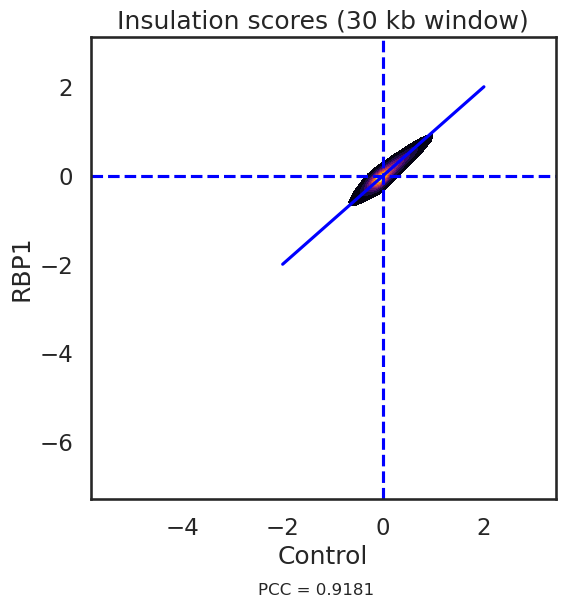

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="white", context="talk")

fig, ax = plt.subplots(figsize=(6,6))
sns.kdeplot(
    x=df["log2_insulation_score_30000_ctrl"],
    y=df["log2_insulation_score_30000_rbp1"],
    fill=True, cmap="inferno", ax=ax, thresh=0.05
)
ax.axhline(0, color="blue", linestyle="--")
ax.axvline(0, color="blue", linestyle="--")
ax.plot([-2,2],[-2,2], color="blue")  # diagonal
ax.set_xlabel("Control")
ax.set_ylabel("RBP1")
plt.title("Insulation scores (30 kb window)")
plt.figtext(0.5, -0.05, f"PCC = {pcc:.4f}", ha="center", fontsize=12)
plt.show()

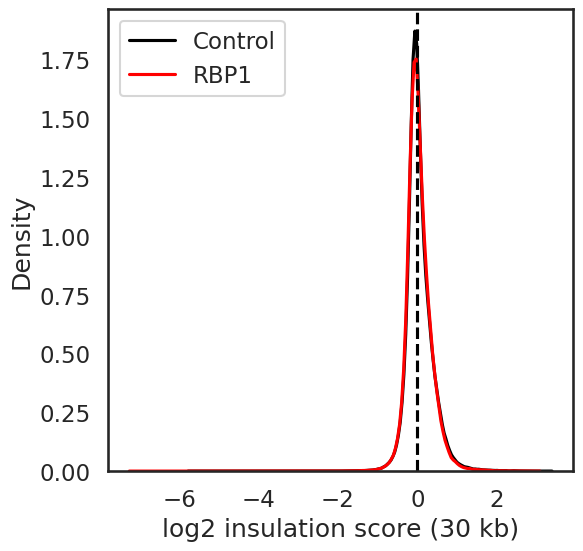

In [5]:
fig, ax = plt.subplots(figsize=(6,6))
sns.kdeplot(df["log2_insulation_score_30000_ctrl"], color="black", label="Control", ax=ax)
sns.kdeplot(df["log2_insulation_score_30000_rbp1"], color="red", label="RBP1", ax=ax)
ax.axvline(0, color="black", linestyle="--")
ax.set_xlabel("log2 insulation score (30 kb)")
ax.set_ylabel("Density")
ax.legend()
plt.show()